<a href="https://colab.research.google.com/github/sathushetty7/retail-demand-forecasting-tft/blob/main/Retail_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import files
files.upload()

import os
os.listdir("/content")

Saving m5_small_tft.csv to m5_small_tft.csv


['.config',
 'm5-forecasting-accuracy.zip',
 'm5_small_tft.csv',
 'm5-forecasting-accuracy (2).zip',
 'm5-forecasting-accuracy (1).zip',
 'sample_data']

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install -q pytorch-forecasting lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 665.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 42.9 MB/s eta 0:00:00


In [17]:
df = pd.read_csv("/content/m5_small_tft.csv")

In [18]:
df.head()

,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1549,0,2015-04-26,11513,Sunday,...,4,2015,NaN,NaN,NaN,NaN,0,0,0,8.26
1,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1550,1,2015-04-27,11513,Monday,...,4,2015,NaN,NaN,NaN,NaN,0,0,0,8.26
2,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1551,0,2015-04-28,11513,Tuesday,...,4,2015,NaN,NaN,NaN,NaN,0,0,0,8.26
3,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1552,0,2015-04-29,11513,Wednesday,...,4,2015,NaN,NaN,NaN,NaN,0,0,0,8.26
4,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1553,0,2015-04-30,11513,Thursday,...,4,2015,NaN,NaN,NaN,NaN,0,0,0,8.26


In [19]:
#TIME-SERIES FEATURE ENGINEERING

df["date"] = pd.to_datetime(df["date"])

# Sort each product-store series chronologically
df = df.sort_values(
    ["item_id", "store_id", "date"]
).reset_index(drop=True)

# Sequential time index
df["time_idx"] = (
    df["date"] - df["date"].min()
).dt.days

# Calendar features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["week"] = df["date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day

# Weekend indicator
df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (73000, 26)


,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,...,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,time_idx,week,day_of_week,day_of_month,is_weekend
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1549,0,2015-04-26,11513,Sunday,...,NaN,0,0,0,8.26,0,17,6,26,1
1,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1550,1,2015-04-27,11513,Monday,...,NaN,0,0,0,8.26,1,18,0,27,0
2,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1551,0,2015-04-28,11513,Tuesday,...,NaN,0,0,0,8.26,2,18,1,28,0
3,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1552,0,2015-04-29,11513,Wednesday,...,NaN,0,0,0,8.26,3,18,2,29,0
4,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1553,0,2015-04-30,11513,Thursday,...,NaN,0,0,0,8.26,4,18,3,30,0


In [20]:
# TIME-BASED TRAIN / VALIDATION SPLIT

max_time = df["time_idx"].max()

# Last 28 days for validation
validation_start = max_time - 27

train_df = df[
    df["time_idx"] < validation_start
].copy()

val_df = df[
    df["time_idx"] >= validation_start
].copy()

print("Training rows  :", len(train_df))
print("Validation rows:", len(val_df))

print("\nTraining period:")
print(train_df["date"].min(), "→", train_df["date"].max())

print("\nValidation period:")
print(val_df["date"].min(), "→", val_df["date"].max())

Training rows  : 67400
Validation rows: 5600

Training period:
2015-04-26 00:00:00 → 2016-03-27 00:00:00

Validation period:
2016-03-28 00:00:00 → 2016-04-24 00:00:00


In [34]:
# BASELINE FORECAST

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Get the last known training sales for each product-store pair
last_train_sales = (
    train_df
    .sort_values("date")
    .groupby(["item_id", "store_id"])["sales"]
    .last()
    .reset_index()
    .rename(columns={"sales": "predicted_sales"})
)

# Merge with validation data
baseline_df = val_df.merge(
    last_train_sales,
    on=["item_id", "store_id"],
    how="left"
)

# Calculate metrics
mae = mean_absolute_error(
    baseline_df["sales"],
    baseline_df["predicted_sales"]
)

rmse = np.sqrt(
    mean_squared_error(
        baseline_df["sales"],
        baseline_df["predicted_sales"]
    )
)

print("===== BASELINE RESULTS =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

===== BASELINE RESULTS =====
MAE  : 1.2261
RMSE : 3.0920


In [33]:
import torch
from pytorch_forecasting import TimeSeriesDataSet

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [32]:
# CREATE TFT DATASET

from pytorch_forecasting import TimeSeriesDataSet

max_encoder_length = 28
max_prediction_length = 7

training = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target="sales",

    group_ids=["item_id", "store_id"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=[
        "item_id",
        "store_id"
    ],

    time_varying_known_reals=[
        "time_idx"
    ],

    time_varying_unknown_reals=[
        "sales"
    ]
)

print("TFT dataset created successfully!")
print("Number of training samples:", len(training))

TFT dataset created successfully!
Number of training samples: 60600


In [37]:
# TFT TRAIN / VALIDATION SETUP

from pytorch_forecasting import TimeSeriesDataSet

max_encoder_length = 28
max_prediction_length = 7

# Use the last 28 days as the validation forecasting period
training_cutoff = df["time_idx"].max() - max_prediction_length - 1

training = TimeSeriesDataSet(
    df[df["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target="sales",

    group_ids=["item_id", "store_id"],

    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,

    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=[
        "item_id",
        "store_id"
    ],

    time_varying_known_reals=[
        "time_idx"
    ],

    time_varying_unknown_reals=[
        "sales"
    ]
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df,
    predict=True,
    stop_randomization=True
)

train_loader = training.to_dataloader(
    train=True,
    batch_size=64,
    num_workers=0
)

val_loader = validation.to_dataloader(
    train=False,
    batch_size=64,
    num_workers=0
)

print("TFT datasets created successfully!")
print("Training samples:", len(training))
print("Validation samples:", len(validation))

TFT datasets created successfully!
Training samples: 64600
Validation samples: 200


In [38]:
# BUILD TFT MODEL

from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

tft = TemporalFusionTransformer.from_dataset(
    training,

    learning_rate=0.03,

    hidden_size=16,
    attention_head_size=4,

    dropout=0.1,

    hidden_continuous_size=8,

    loss=QuantileLoss(),

    output_size=7,

    log_interval=10,

    reduce_on_plateau_patience=4
)

print(tft)

TemporalFusionTransformer(
  	"attention_head_size":               4
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'sales', 'group_ids': ['item_id', 'store_id'], 'weight': None, 'max_encoder_length': 28, 'min_encoder_length': 28, 'min_prediction_idx': 0, 'min_prediction_length': 7, 'max_prediction_length': 7, 'static_categoricals': ['item_id', 'store_id'], 'static_reals': None, 'time_varying_known_categoricals': None, 'time_varying_known_reals': ['time_idx'], 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['sales'], 'variable_groups': None, 'constant_fill_strategy': None, 'allow_missing_timesteps': False, 'lags': None, 'add_relative_time_idx': False, 'add_target_scales': False, 'add_encoder_length': False, 'target_normalizer': NaNLabelEncoder(add_nan=False, warn=True), 'categorical_encoders': {'__group_id__item_id': NaNLabelEncoder(add_nan=False

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [39]:
# TRAIN TFT MODEL

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=3,
    mode="min"
)

lr_logger = LearningRateMonitor()

trainer = pl.Trainer(
    max_epochs=20,
    accelerator="auto",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[
        early_stop_callback,
        lr_logger
    ],
    enable_model_summary=True
)

trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  3.2 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     32 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │    160 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  1.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    528 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 18.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 18.9 K                                                                                               
Total estimated model params size (MB): 0.075                                                                      
Modules in train mode: 199                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

In [42]:
# STEP 7 — EVALUATE TFT

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Generate predictions
predictions = tft.predict(
    val_loader,
    mode="prediction"
)

# Convert predictions to numpy
y_pred = predictions.detach().cpu().numpy()

# Get actual values
actuals = torch.cat([
    y[0] for x, y in iter(val_loader)
]).detach().cpu().numpy()

# Flatten if necessary
y_pred = y_pred.reshape(-1)
actuals = actuals.reshape(-1)

# Calculate metrics
tft_mae = mean_absolute_error(
    actuals,
    y_pred
)

tft_rmse = np.sqrt(
    mean_squared_error(
        actuals,
        y_pred
    )
)

print("\nTFT RESULTS ")
print(f"MAE  : {tft_mae:.4f}")
print(f"RMSE : {tft_rmse:.4f}")

print("\n COMPARISON ")
print(f"Baseline MAE : 1.2261")
print(f"TFT MAE      : {tft_mae:.4f}")

print(f"\nBaseline RMSE: 3.0920")
print(f"TFT RMSE     : {tft_rmse:.4f}")

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities


TFT RESULTS 
MAE  : 0.8973
RMSE : 2.2973

 COMPARISON 
Baseline MAE : 1.2261
TFT MAE      : 0.8973

Baseline RMSE: 3.0920
TFT RMSE     : 2.2973


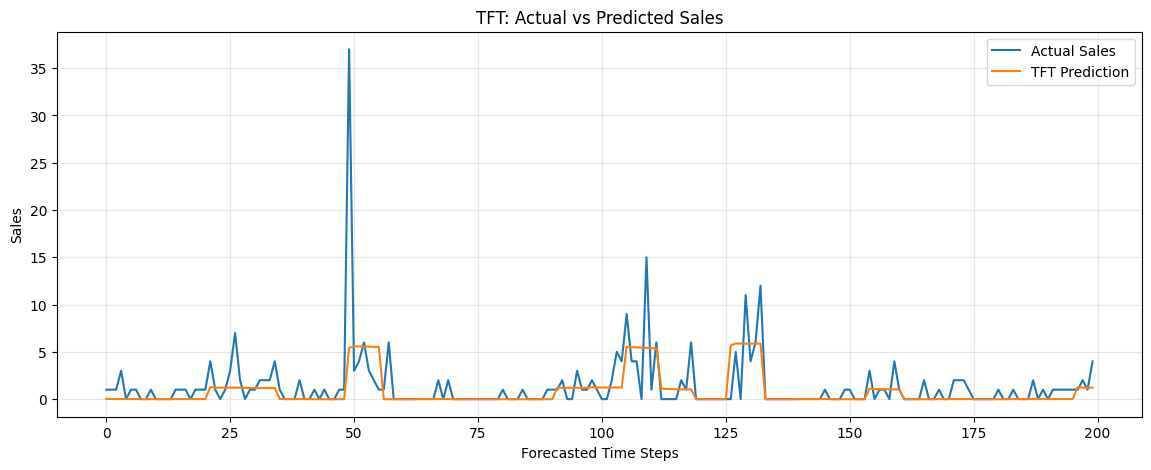

In [43]:
# ACTUAL VS PREDICTED

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    actuals[:200],
    label="Actual Sales"
)

plt.plot(
    y_pred[:200],
    label="TFT Prediction"
)

plt.title("TFT: Actual vs Predicted Sales")
plt.xlabel("Forecasted Time Steps")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [44]:
# STEP 9 — FINAL MODEL COMPARISON

import pandas as pd

baseline_mae = 1.2261
baseline_rmse = 3.0920

comparison = pd.DataFrame({
    "Model": ["Naive Baseline", "TFT"],
    "MAE": [baseline_mae, tft_mae],
    "RMSE": [baseline_rmse, tft_rmse]
})

display(
    comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

mae_improvement = (
    (baseline_mae - tft_mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - tft_rmse) / baseline_rmse
) * 100

print(f"MAE Improvement : {mae_improvement:.2f}%")
print(f"RMSE Improvement: {rmse_improvement:.2f}%")

,Model,MAE,RMSE
0,Naive Baseline,1.2261,3.0920
1,TFT,0.8973,2.2973


MAE Improvement : 26.81%
RMSE Improvement: 25.70%
